# Joining Land Registry Price Data with Energy Performance Certificates (2015 - 2025)

#### Load Price data

In [342]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)


folder = Path('../data/raw')
file_gen = folder.glob('ppd_data*.csv')
pp_raw = pd.concat([pd.read_csv(f) for f in file_gen], ignore_index=True)
pp_raw['deed_date'] = pp_raw['deed_date'].astype('datetime64[ns]')

#### Load EPC data

In [343]:
epc_raw = pd.read_csv('../data/raw/EDC_OXFORDSHIRE_2015_2025.csv', usecols= [
    'certificate_number', 'address1', 'address2', 'address3', 'postcode',
    'posttown', 'address', 'local_authority', 'local_authority_label',
    'built_form', 'construction_age_band', 'current_energy_efficiency',
    'current_energy_rating', 'energy_consumption_current', 'extension_count', 'floor_height', 'heating_cost_current',
    'inspection_date', 'lodgement_date', 'number_habitable_rooms',
    'number_heated_rooms', 'potential_energy_efficiency', 'property_type',
    'tenure', 'total_floor_area', 'transaction_type', 'uprn', 'uprn_source'
])
epc_raw['inspection_date'] = epc_raw['inspection_date'].astype('datetime64[ns]')
epc_raw['lodgement_date'] = epc_raw['lodgement_date'].astype('datetime64[ns]')

#### Cleaning

Fix trailing whitespace

In [344]:
pp = pp_raw.copy()

for c in pp.select_dtypes(include=['string']).columns:
    pp[c] = pp[c].str.strip()
    print(f"{c} stripped")

unique_id stripped
postcode stripped
property_type stripped
new_build stripped
estate_type stripped
saon stripped
paon stripped
street stripped
locality stripped
town stripped
district stripped
county stripped
transaction_category stripped
linked_data_uri stripped


In [345]:
epc = epc_raw.copy()

for c in epc.select_dtypes(include=['string']).columns:
    epc[c] = epc[c].str.strip()
    print(f"{c} stripped")

certificate_number stripped
address1 stripped
address2 stripped
address3 stripped
postcode stripped
posttown stripped
address stripped
local_authority stripped
local_authority_label stripped
built_form stripped
construction_age_band stripped
current_energy_rating stripped
property_type stripped
tenure stripped
transaction_type stripped
uprn_source stripped


Remove commas

In [346]:
epc_address_cols = ['address1', 'address2', 'address3', 'postcode']
pp_address_cols = ['paon', 'saon', 'street', 'locality', 'postcode']

print(f"Commas replaced in epc:\n{epc[epc_address_cols].apply(lambda col: col.str.count(',')).sum()}")
print(f"Commas replaced in pp:\n{pp[pp_address_cols].apply(lambda col: col.str.count(',')).sum()}")

for c in epc_address_cols:
    epc[c] = epc[c].str.replace(',', '', regex=False)
for c in pp_address_cols:
    pp[c] = pp[c].str.replace(',', '', regex=False)

Commas replaced in epc:
address1    83515.0
address2     3910.0
address3      137.0
postcode        0.0
dtype: float64
Commas replaced in pp:
paon        4356.0
saon          33.0
street         0.0
locality       0.0
postcode       0.0
dtype: float64


Generate address token sets

In [347]:
pp['address'] = pp['paon'].str.cat([pp['saon'], pp['street'], pp['locality'], pp['postcode']], sep=' ', na_rep='')
epc['address'] = epc['address1'].str.cat([epc['address2'], epc['address3'], epc['postcode']], sep=' ', na_rep='').apply(str.upper)

In [348]:
pp['address_tokens'] = pp['address'].str.split().apply(frozenset)
epc['address_tokens'] = epc['address'].str.split().apply(frozenset)

#### Third Join (subset matching)

In [349]:
postcode_match = pp.merge(epc, on='postcode', how='inner')

def compare(row):
    return row['address_tokens_x'].issubset(row['address_tokens_y'])

postcode_match['result'] = postcode_match.apply(compare, axis=1)

In [350]:
epc['uprn'] = epc['uprn'].astype('Int64')

In [351]:
subset_matches = postcode_match[postcode_match['result']]

print(f"Third join (subset method) gives: {subset_matches['unique_id'].nunique()} matches. A matching rate of {100 * subset_matches['unique_id'].nunique()/pp.shape[0]:.1f}%")

Third join (subset method) gives: 105419 matches. A matching rate of 77.8%


Finding records where duplicate words were lost from the address in token setting

In [352]:
multi_match = subset_matches.groupby('unique_id')['uprn'].nunique()
multi_uprn = multi_match[multi_match > 1]

pp['token_count'] = pp['address'].str.count(r"\S+")
lost_tokens = pp[pp['token_count'] > pp['address_tokens'].apply(len)]
result = lost_tokens[lost_tokens['unique_id'].isin(multi_uprn.index)]

Date filtering

In [353]:
third_join = subset_matches[~subset_matches['unique_id'].isin(multi_uprn.index)]
third_join['time_to_sale'] = third_join['deed_date'] - third_join['inspection_date']

drop_neg = third_join[third_join['time_to_sale'] >= '0 days']
third_join_presale_epc = drop_neg.sort_values(by='time_to_sale', ascending=True).drop_duplicates(subset='unique_id')
print(f"Properties remaining with matched pre-sale EPCs: {third_join_presale_epc.shape[0]}")
print(f"Corresponds to a {100 * third_join_presale_epc.shape[0]/pp.shape[0]:.1f}% match rate")

Properties remaining with matched pre-sale EPCs: 91150
Corresponds to a 67.2% match rate


Drop matching and helping columns

In [354]:
cols_to_keep = ['unique_id', 'price_paid', 'deed_date', 'address_x', 'saon', 'paon', 'street', 'locality', 'town', 'district',  
                'postcode', 'property_type_x', 'new_build', 'estate_type',  'transaction_category',  'certificate_number', 
                'built_form', 'construction_age_band', 'current_energy_efficiency', 'current_energy_rating', 
                'energy_consumption_current', 'extension_count', 'floor_height', 'heating_cost_current', 
                'inspection_date', 'lodgement_date', 'number_habitable_rooms', 'number_heated_rooms', 
                'potential_energy_efficiency', 'property_type_y', 'tenure', 'total_floor_area', 
                'transaction_type', 'uprn', 'uprn_source', 'time_to_sale']

df = third_join_presale_epc[cols_to_keep]
df = df.rename(columns={'property_type_x':'property_subtype', 'property_type_y':'property_type', 'time_to_sale':'inspection_to_sale'})


Create EPC age bands from 'inspection_to_sale'

In [355]:
df['inspection_to_sale'] = df['inspection_to_sale'].dt.days

bins = [0, 365, 1095, 1825, 3650, np.inf]
labels = ['0-1 years', '1-3 years', '3-5 years', '5-10 years', '10 years+']

df['EPC_age_band'] = pd.cut(df['inspection_to_sale'], bins=bins, labels=labels, include_lowest=True)

Add flag for expired EPCs (10 years from lodgement_date)

In [356]:
df['EPC_expired'] = ((df['deed_date'] > (df['lodgement_date'] + pd.DateOffset(years=10))))

Adding datetime calendar features to joined/matched data

In [357]:
df['dayofweek'] = df['deed_date'].dt.dayofweek
df['day'] = df['deed_date'].dt.day
df['month'] = df['deed_date'].dt.month
df['quarter'] = df['deed_date'].dt.quarter
df['year'] = df['deed_date'].dt.year

## Missing data

#### Convert invalid values identified in part 1 to null

In [358]:
print(f"Number of records with zero 'number_heated_rooms': {(df['number_heated_rooms'] == 0).sum()}")
print('Converting 0 to NaN...')
df.loc[df['number_heated_rooms'] == 0, 'number_heated_rooms'] = np.nan

print(f"Number of records with zero 'number_heated_rooms': {(df['number_heated_rooms'] == 0).sum()}")

Number of records with zero 'number_heated_rooms': 134
Converting 0 to NaN...
Number of records with zero 'number_heated_rooms': 0


In [359]:
print(f"Number of records with 'floor_height' < 1.5m : {(df['floor_height'] < 1.5).sum()}")
print('Converting to NaN...')
df.loc[df['floor_height'] < 1.5, 'floor_height'] = np.nan

print(f"Number of records with 'floor_height' < 1.5m : {(df['floor_height'] < 1.5).sum()}")

Number of records with 'floor_height' < 1.5m : 1429
Converting to NaN...
Number of records with 'floor_height' < 1.5m : 0


In [360]:
print(f"Number of records with 'property_type' as 'Not Recorded' : {(df['property_type'] == 'Not Recorded').sum()}")
print('Converting to NaN...')
df.loc[df['property_type'] == 'Not Recorded', 'property_type'] = np.nan

print(f"Number of records with 'property_type' as 'Not Recorded' : {(df['property_type'] == 'Not Recorded').sum()}")
df['property_type'].value_counts(dropna=False)

Number of records with 'property_type' as 'Not Recorded' : 0
Converting to NaN...
Number of records with 'property_type' as 'Not Recorded' : 0


property_type
House         74198
Flat          10084
Bungalow       5864
Maisonette      994
NaN               8
Park home         2
Name: count, dtype: int64

In [361]:
df['tenure'].value_counts(dropna=False)

tenure
owner-occupied      63106
unknown             21458
rented (private)     6174
rented (social)       412
Name: count, dtype: int64

In [362]:
print(f"Number of records with 'tenure' as 'unknown' : {(df['tenure'] == 'unknown').sum()}")
print('Converting to NaN...')
df.loc[df['tenure'] == 'unknown', 'tenure'] = np.nan

print(f"Number of records with 'tenure' as 'unknown' : {(df['tenure'] == 'unknown').sum()}")

Number of records with 'tenure' as 'unknown' : 21458
Converting to NaN...
Number of records with 'tenure' as 'unknown' : 0


#### Measure missingness

In [363]:
print(pd.concat([df.isna().sum(), df.isna().mean()], axis=1, keys=['count', 'normalized']))

                             count  normalized
unique_id                        0    0.000000
price_paid                       0    0.000000
deed_date                        0    0.000000
address_x                        0    0.000000
saon                         85246    0.935228
paon                             0    0.000000
street                        1719    0.018859
locality                     54337    0.596127
town                             0    0.000000
district                         0    0.000000
postcode                         0    0.000000
property_subtype                 0    0.000000
new_build                        0    0.000000
estate_type                      0    0.000000
transaction_category             0    0.000000
certificate_number               0    0.000000
built_form                    2009    0.022041
construction_age_band            0    0.000000
current_energy_efficiency        0    0.000000
current_energy_rating            0    0.000000
energy_consum

In [364]:

fields_miss = df.isna().mean().reset_index()

fields_miss.columns = ['field_name', 'missing']
fields_miss['missing'] = round(fields_miss['missing'] * 100, 2)
fields_miss = fields_miss.set_index(keys='field_name')
print(fields_miss)

                             missing
field_name                          
unique_id                       0.00
price_paid                      0.00
deed_date                       0.00
address_x                       0.00
saon                           93.52
paon                            0.00
street                          1.89
locality                       59.61
town                            0.00
district                        0.00
postcode                        0.00
property_subtype                0.00
new_build                       0.00
estate_type                     0.00
transaction_category            0.00
certificate_number              0.00
built_form                      2.20
construction_age_band           0.00
current_energy_efficiency       0.00
current_energy_rating           0.00
energy_consumption_current      0.00
extension_count                32.33
floor_height                    2.25
heating_cost_current            0.00
inspection_date                 0.00
l

#### Apply part 1 exclusions

- *Proposed: Exclude these 7 records with multiple rooms and < 9 sqm. Exclude the record with 3 sqm. Flag the 19 records that are 1 room flats (7-9 sqm) and check sale prices after join before deciding.*
- *Proposed: Exclude the 7 records with >2000 sqm and <= 7 rooms (8206-7322-4290-4245-7906, 0552-3041-5201-3644-6204, 1032-5920-2209-0815-0202, 0044-2876-6518-9608-3961, 8171-6324-5580-7887-6996, 3434-1132-3000-0328-7226, 5135-0635-7000-0689-9206)*
- Two have energy_consumption_current >200 and are Maisonette/Flat which flags them as likely errors. *Proposed: Exclude 2051-7735-3040-1307-9975 and 0061-1212-2504-8687-0900*
-  `construction_age_band` exclude 201 as an error

Checking for propertes with <= 9 sqm total_floor_area.

In [365]:
print(df[df['total_floor_area'] <= 9])
print(df.shape)
df = df[~(df['total_floor_area'] <= 9)]
print(df.shape)

                                    unique_id  price_paid  deed_date                 address_x saon paon      street locality    town          district  postcode property_subtype new_build estate_type transaction_category        certificate_number   built_form         construction_age_band  current_energy_efficiency current_energy_rating  energy_consumption_current  extension_count  floor_height  heating_cost_current inspection_date lodgement_date  number_habitable_rooms  number_heated_rooms  potential_energy_efficiency property_type          tenure  total_floor_area transaction_type          uprn      uprn_source  inspection_to_sale EPC_age_band  EPC_expired  dayofweek  day  month  quarter  year
2584364  44F406B6-C504-1095-E063-4704A8C048D4      107250 2025-10-24  24  MANOR ROAD  OX28 3SR  NaN   24  MANOR ROAD      NaN  WITNEY  WEST OXFORDSHIRE  OX28 3SR                F         N           L                    A  0360-2874-6282-9391-2035  End-Terrace  England and Wales: 1983-1990    

- Dropped 1 property with 9 sqm floor area and 2 rooms

Checking for the 7 high floor area records flagged for exclusion (>2000 sqm and <= 7 rooms)

In [366]:
print(df[df['certificate_number'].isin(['8206-7322-4290-4245-7906', 
                               '0552-3041-5201-3644-6204', 
                               '1032-5920-2209-0815-0202', 
                               '0044-2876-6518-9608-3961', 
                               '8171-6324-5580-7887-6996', 
                               '3434-1132-3000-0328-7226', 
                               '5135-0635-7000-0689-9206'])])

df = df[~df['certificate_number'].isin(['8206-7322-4290-4245-7906', 
                               '0552-3041-5201-3644-6204', 
                               '1032-5920-2209-0815-0202', 
                               '0044-2876-6518-9608-3961', 
                               '8171-6324-5580-7887-6996', 
                               '3434-1132-3000-0328-7226', 
                               '5135-0635-7000-0689-9206'])]

print(df.shape)

                                    unique_id  price_paid  deed_date                           address_x saon             paon         street    locality              town           district postcode property_subtype new_build estate_type transaction_category        certificate_number     built_form           construction_age_band  current_energy_efficiency current_energy_rating  energy_consumption_current  extension_count  floor_height  heating_cost_current inspection_date lodgement_date  number_habitable_rooms  number_heated_rooms  potential_energy_efficiency property_type          tenure  total_floor_area transaction_type          uprn      uprn_source  inspection_to_sale EPC_age_band  EPC_expired  dayofweek  day  month  quarter  year
1715797  34428D7E-6659-B86C-E050-A8C06205059C      926100 2016-05-13  THE OLD LAUNDRY   HARPSDEN RG9 4HL  NaN  THE OLD LAUNDRY            NaN    HARPSDEN  HENLEY-ON-THAMES  SOUTH OXFORDSHIRE  RG9 4HL                D         N           F              

- 3 in dataset, excluded

Two records have current_energy_efficiency > 110, energy_consumption_current >200 and are Maisonette/Flat which flags them as likely errors (2051-7735-3040-1307-9975 and 0061-1212-2504-8687-0900)

In [367]:
print(df[df['certificate_number'].isin(['2051-7735-3040-1307-9975', 
                               '0061-1212-2504-8687-0900'])])

Empty DataFrame
Columns: [unique_id, price_paid, deed_date, address_x, saon, paon, street, locality, town, district, postcode, property_subtype, new_build, estate_type, transaction_category, certificate_number, built_form, construction_age_band, current_energy_efficiency, current_energy_rating, energy_consumption_current, extension_count, floor_height, heating_cost_current, inspection_date, lodgement_date, number_habitable_rooms, number_heated_rooms, potential_energy_efficiency, property_type, tenure, total_floor_area, transaction_type, uprn, uprn_source, inspection_to_sale, EPC_age_band, EPC_expired, dayofweek, day, month, quarter, year]
Index: []


- Neither record in set

`construction_age_band` exclude 201 as an error

In [368]:
print(df.loc[df['construction_age_band'].apply(len) < 4, 'construction_age_band'])

df = df[df['construction_age_band'].apply(len) >= 4]

df.shape

2055929    201
2055958    201
2055900    201
Name: construction_age_band, dtype: str


(91143, 43)

- Excluded 3 records with 'construction_age_band' = '201'

#### Addressing columns with missing values

New dwellings are systematically missing room counts from initial EPCs. Can they be filled from subsequent records?

In [369]:

epc_raw = pd.read_csv('../data/raw/EDC_OXFORDSHIRE_2015_2025.csv', usecols= [
    'certificate_number', 'address1', 'address2', 'address3', 'postcode',
    'posttown', 'address', 'local_authority', 'local_authority_label',
    'built_form', 'construction_age_band', 'current_energy_efficiency',
    'current_energy_rating', 'energy_consumption_current', 'extension_count', 'floor_height', 'heating_cost_current',
    'inspection_date', 'lodgement_date', 'number_habitable_rooms',
    'number_heated_rooms', 'potential_energy_efficiency', 'property_type',
    'tenure', 'total_floor_area', 'transaction_type', 'uprn', 'uprn_source'
])
epc_raw['inspection_date'] = epc_raw['inspection_date'].astype('datetime64[ns]')
epc_raw['lodgement_date'] = epc_raw['lodgement_date'].astype('datetime64[ns]')




In [370]:
num_to_fill = ((df['transaction_type'] == 'New dwelling') & (df['number_heated_rooms'].isna())).sum()
print(f"There are {num_to_fill} New dwellings in the joined set with no value for 'number_heated_rooms'")

nd_nanroom_uprn = df['uprn'][((df['transaction_type'] == 'New dwelling') & (df['number_heated_rooms'].isna()))].values # uprn's for the properties with missing rooms

nd_nanroom = epc_raw[epc_raw['uprn'].isin(nd_nanroom_uprn)] # uprn matching records in the raw set

nd_room_count = nd_nanroom.groupby('uprn')['number_heated_rooms'].count() # how many records for each uprn

nd_multi_idx = nd_room_count[nd_room_count > 0].index # filter to uprn's with multiple records

nd_multi_record = epc_raw[epc_raw['uprn'].isin(nd_multi_idx)].dropna(subset='number_heated_rooms') # extract records with room values

print(f"Filling from other certificates adds a maximum of {nd_multi_record.nunique()['uprn']} records ({100 * nd_multi_record.nunique()['uprn']/num_to_fill:.1f}%)")




There are 27473 New dwellings in the joined set with no value for 'number_heated_rooms'
Filling from other certificates adds a maximum of 583 records (2.1%)


- Investigated if rows with missing rooms could be filled from post-sale EPC records
    - There are 27473 New dwellings in the joined set with no value for 'number_heated_rooms', 'number_habitable_rooms' and 'extension_count'
    - Filtering for these properties (via uprn) in the raw EPC set finds 583 records that could be used for filling. This represents only 2.1% of the New dwelling properties with missing values. Filling not implemented.

In [371]:
print(pd.concat([df[df['transaction_type'] == 'New dwelling']['new_build'].value_counts(), df[df['transaction_type'] == 'New dwelling']['new_build'].value_counts(normalize=True)], axis=1))



           count  proportion
new_build                   
Y          18965    0.690314
N           8508    0.309686


- 31% of properties labelled New dwelling (from EPC) are not flagged as new_build (from price paid)
- Possible they were new viewed as new at the time of sale?

Missing floor_height

In [372]:
print(df['floor_height'].isna().sum())

print(pd.concat([df['property_type'][df['floor_height'].isna()].value_counts(), df['property_type'][df['floor_height'].isna()].value_counts(normalize=True)], axis=1))

2049
               count  proportion
property_type                   
House           1176    0.573939
Flat             704    0.343582
Bungalow         166    0.081015
Maisonette         2    0.000976
Park home          1    0.000488


'floor_height' distribution for houses:
count    73016.000000
mean         2.371809
std          0.154520
min          1.500000
25%          2.300000
50%          2.370000
75%          2.410000
max          7.000000
Name: floor_height, dtype: float64
'floor_height' distribution for flats:
count    9380.000000
mean        2.405749
std         0.205171
min         1.700000
25%         2.300000
50%         2.380000
75%         2.430000
max         6.950000
Name: floor_height, dtype: float64
'floor_height' distribution for bungalow:
count    5698.000000
mean        2.393893
std         0.166116
min         1.500000
25%         2.320000
50%         2.390000
75%         2.420000
max         5.200000
Name: floor_height, dtype: float64

'floor_height' distribution for all types:
count    89094.000000
mean         2.377064
std          0.162560
min          1.500000
25%          2.300000
50%          2.370000
75%          2.410000
max          7.000000
Name: floor_height, dtype: float64


<Axes: xlabel='floor_height', ylabel='property_type'>

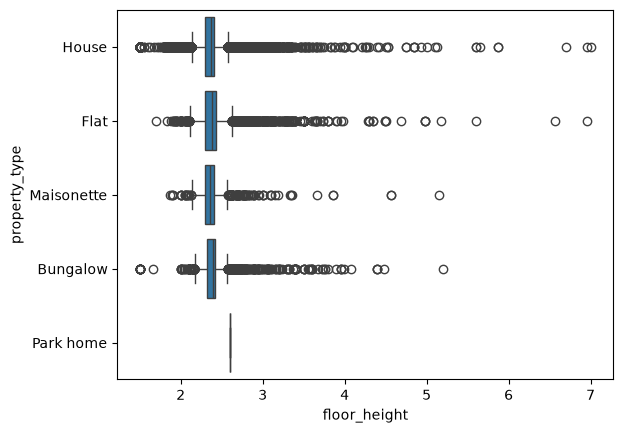

In [373]:
print("'floor_height' distribution for houses:")
print(df[df['property_type'] == 'House']['floor_height'].describe())

print("'floor_height' distribution for flats:")
print(df[df['property_type'] == 'Flat']['floor_height'].describe())

print("'floor_height' distribution for bungalow:")
print(df[df['property_type'] == 'Bungalow']['floor_height'].describe())

print("\n'floor_height' distribution for all types:")
print(df['floor_height'].describe())

sns.boxplot(df, x='floor_height', y='property_type')

Fill missing floor_height with median

In [374]:
df['floor_height_imputed'] = df['floor_height'].isna()
print(df['floor_height_imputed'].value_counts())
df['floor_height'] = df['floor_height'].fillna(df['floor_height'].median())
print(f"\nRemaining missing floor_height: {df['floor_height'].isna().sum()}")

floor_height_imputed
False    89094
True      2049
Name: count, dtype: int64

Remaining missing floor_height: 0


In [375]:

missing_rooms = df[(df['transaction_type'] != 'New dwelling') & (df['number_heated_rooms'].isna())]
not_missing_rooms = df[(df['transaction_type'] != 'New dwelling') & (~df['number_heated_rooms'].isna())]
print(f"There are {missing_rooms.shape[0]} properties with missing rooms (excluding New dwelling transaction_type)\n")
to_check = ['transaction_type', 'property_type', 'built_form']

for c in to_check:
    print(pd.concat([missing_rooms[c].value_counts(),missing_rooms[c].value_counts(normalize=True),  not_missing_rooms[c].value_counts(), not_missing_rooms[c].value_counts(normalize=True)], axis=1, keys=[('missing_rooms', 'count'), ('missing_rooms', 'normalized'), ('not_missing_rooms', 'count'), ('not_missing_rooms', 'normalized')]))

print(missing_rooms['total_floor_area'].describe())
print(not_missing_rooms['total_floor_area'].describe())

There are 2130 properties with missing rooms (excluding New dwelling transaction_type)

                          missing_rooms            not_missing_rooms           
                                  count normalized             count normalized
transaction_type                                                               
Marketed sale                    1549.0   0.727230             53070   0.862562
None of the above                 545.0   0.255869               371   0.006030
Rental                             15.0   0.007042              6450   0.104834
Non-marketed sale                  14.0   0.006573               746   0.012125
FiT application                     6.0   0.002817               125   0.002032
Assessment for Green Deal           1.0   0.000469               175   0.002844
ECO assessment                      NaN        NaN               444   0.007216
RHI application                     NaN        NaN                91   0.001479
Stock condition survey          

- With transaction_type = 'New dwelling' excluded. Comparing properties with missing rooms against those without missing rooms:
    - transaction_type = 'None of the above' is over-represented (26% vs 0.6%) and all others under-represented
    - property_type is more likely to be House (86% vs 80%) and less likely to be Bungalow (1.6% vs 9%) or Maisonette (0.4% vs 1.3%)
    - built_form is more likely to be Detatched (51% vs 31%) and less likely to be all others particularly Mid-Terrace (21% vs 10%)

In [376]:
print(f"Number of records with 'built_form' as 'Not Recorded' : {(df['built_form'] == 'Not Recorded').sum()}")
print('Converting to NaN...')
df.loc[df['built_form'] == 'Not Recorded', 'built_form'] = np.nan

print(f"Number of records with 'built_form' as 'Not Recorded' : {(df['built_form'] == 'Not Recorded').sum()}")
df['built_form'].value_counts(dropna=False)

Number of records with 'built_form' as 'Not Recorded' : 27
Converting to NaN...
Number of records with 'built_form' as 'Not Recorded' : 0


built_form
Detached                32497
Semi-Detached           29165
Mid-Terrace             15567
End-Terrace             10510
NaN                      2036
Enclosed End-Terrace      833
Enclosed Mid-Terrace      535
Name: count, dtype: int64